---
## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Global plot styling
sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})

print('Libraries loaded successfully.')

Libraries loaded successfully.


---
## 2. Load Data

In [2]:
# ── Update this path if needed ──────────────────────────────────────────────
CSV_PATH = r'C:\Users\kyipp\OneDrive\Documents\Masters\Data Analytics\Lab 2\WorldEnergy.csv'
# ────────────────────────────────────────────────────────────────────────────

df = pd.read_csv(CSV_PATH)
print(f'Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')

Loaded: 23,195 rows × 130 columns


---
## 3. Basic Structure Inspection

In [3]:
print('=== SHAPE ===')
print(f'{df.shape[0]:,} rows, {df.shape[1]} columns\n')

print('=== FIRST 5 ROWS ===')
df.head()

=== SHAPE ===
23,195 rows, 130 columns

=== FIRST 5 ROWS ===


,country,year,iso_code,population,gdp,biofuel_cons_change_pct,biofuel_cons_change_twh,biofuel_cons_per_capita,biofuel_consumption,biofuel_elec_per_capita,...,solar_share_elec,solar_share_energy,wind_cons_change_pct,wind_cons_change_twh,wind_consumption,wind_elec_per_capita,wind_electricity,wind_energy_per_capita,wind_share_elec,wind_share_energy
0,ASEAN (Ember),2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
1,ASEAN (Ember),2001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
2,ASEAN (Ember),2002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
3,ASEAN (Ember),2003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
4,ASEAN (Ember),2004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN


In [4]:
print('=== COLUMN DATA TYPES ===')
print(df.dtypes.value_counts())
print()

print('=== STRING COLUMNS ===')
str_cols = df.select_dtypes(include='object').columns.tolist()
print(str_cols)

print()
print('=== NUMERIC COLUMNS COUNT ===')
num_cols = df.select_dtypes(include='number').columns.tolist()
print(f'{len(num_cols)} numeric columns')

=== COLUMN DATA TYPES ===
float64    127
str          2
int64        1
Name: count, dtype: int64

=== STRING COLUMNS ===
['country', 'iso_code']

=== NUMERIC COLUMNS COUNT ===
128 numeric columns


In [5]:
print('=== BASIC STATS (Key Columns) ===')
key_cols = ['year', 'population', 'gdp',
            'primary_energy_consumption', 'fossil_share_energy',
            'renewables_share_energy', 'coal_share_energy',
            'solar_share_energy', 'wind_share_energy']
df[key_cols].describe().round(2)

=== BASIC STATS (Key Columns) ===


,year,population,gdp,primary_energy_consumption,fossil_share_energy,renewables_share_energy,coal_share_energy,solar_share_energy,wind_share_energy
count,23195.00,1.872900e+04,1.178000e+04,13255.00,6379.00,6379.00,6379.00,6379.00,6379.00
mean,1975.86,1.010849e+08,4.257565e+11,4254.77,86.07,11.12,18.22,0.22,0.52
std,35.21,4.606079e+08,3.507870e+12,14897.51,14.52,13.27,19.04,0.77,1.72
min,1900.00,1.733000e+03,1.642060e+08,0.00,13.87,0.00,0.00,0.00,0.00
25%,1949.00,1.596265e+06,1.426394e+10,8.00,80.82,2.13,2.00,0.00,0.00
50%,1985.00,6.875000e+06,4.357680e+10,91.19,90.36,6.55,12.56,0.00,0.00
75%,2005.00,2.531192e+07,1.830576e+11,772.24,96.66,15.01,29.61,0.01,0.07
max,2024.00,8.161972e+09,1.301126e+14,176737.09,100.00,86.13,89.16,9.88,26.08


In [6]:
print('=== COVERAGE ===')
print(f"Countries/Entities : {df['country'].nunique()}")
print(f"Year range         : {int(df['year'].min())} – {int(df['year'].max())}")

# Distinguish actual countries vs regional aggregates
actual_countries = df[df['iso_code'].notna()]['country'].nunique()
regional_groups  = df[df['iso_code'].isna()]['country'].nunique()
print(f"Actual countries   : {actual_countries}")
print(f"Regional aggregates: {regional_groups}")

print()
print('=== REGIONAL / AGGREGATE ENTITIES (no ISO code) ===')
print(df[df['iso_code'].isna()]['country'].unique())

=== COVERAGE ===
Countries/Entities : 314
Year range         : 1900 – 2024
Actual countries   : 220
Regional aggregates: 94

=== REGIONAL / AGGREGATE ENTITIES (no ISO code) ===
<StringArray>
[                        'ASEAN (Ember)',
                                'Africa',
                           'Africa (EI)',
                          'Africa (EIA)',
                        'Africa (Ember)',
                        'Africa (Shift)',
                                  'Asia',
                  'Asia & Oceania (EIA)',
                          'Asia (Ember)',
                     'Asia Pacific (EI)',
              'Asia and Oceania (Shift)',
       'Australia and New Zealand (EIA)',
                              'CIS (EI)',
         'Central & South America (EIA)',
                  'Central America (EI)',
     'Central and South America (Shift)',
                        'Czechoslovakia',
                            'EU (Ember)',
                          'EU28 (Shift)',
           

---
## 4. Missing Data Analysis

> **Note:** High missingness in this dataset is expected — many metrics (e.g. solar, wind) were
> genuinely zero or unreported before the 1980s–1990s. Always contextualise missingness against the year range.

In [7]:
# ── Overall missing summary ──────────────────────────────────────────────────
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %':     (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Missing %', ascending=False)

missing_nonzero = missing[missing['Missing Count'] > 0]

print(f'Columns with any missing data: {len(missing_nonzero)} / {df.shape[1]}')
print()
print('=== TOP 20 COLUMNS BY MISSING % ===')
print(missing_nonzero.head(20).to_string())

Columns with any missing data: 128 / 130

=== TOP 20 COLUMNS BY MISSING % ===
                                              Missing Count  Missing %
biofuel_cons_change_pct                               21125      91.08
solar_cons_change_pct                                 20680      89.16
nuclear_cons_change_pct                               20616      88.88
wind_cons_change_pct                                  20397      87.94
other_renewables_cons_change_pct                      19207      82.81
electricity_share_energy                              18780      80.97
low_carbon_energy_per_capita                          18050      77.82
oil_energy_per_capita                                 18050      77.82
coal_cons_per_capita                                  18050      77.82
fossil_energy_per_capita                              18050      77.82
gas_energy_per_capita                                 18050      77.82
hydro_energy_per_capita                               18050      77.82

In [8]:
# ── Categorise columns by missingness severity ───────────────────────────────
def classify_missing(pct):
    if pct == 0:       return 'Complete'
    elif pct <= 20:    return 'Low (<20%)'
    elif pct <= 50:    return 'Moderate (20–50%)'
    elif pct <= 80:    return 'High (50–80%)'
    else:              return 'Very High (>80%)'

missing['Category'] = missing['Missing %'].apply(classify_missing)
print(missing['Category'].value_counts())

Category
High (50–80%)        107
Moderate (20–50%)     14
Very High (>80%)       6
Complete               2
Low (<20%)             1
Name: count, dtype: int64


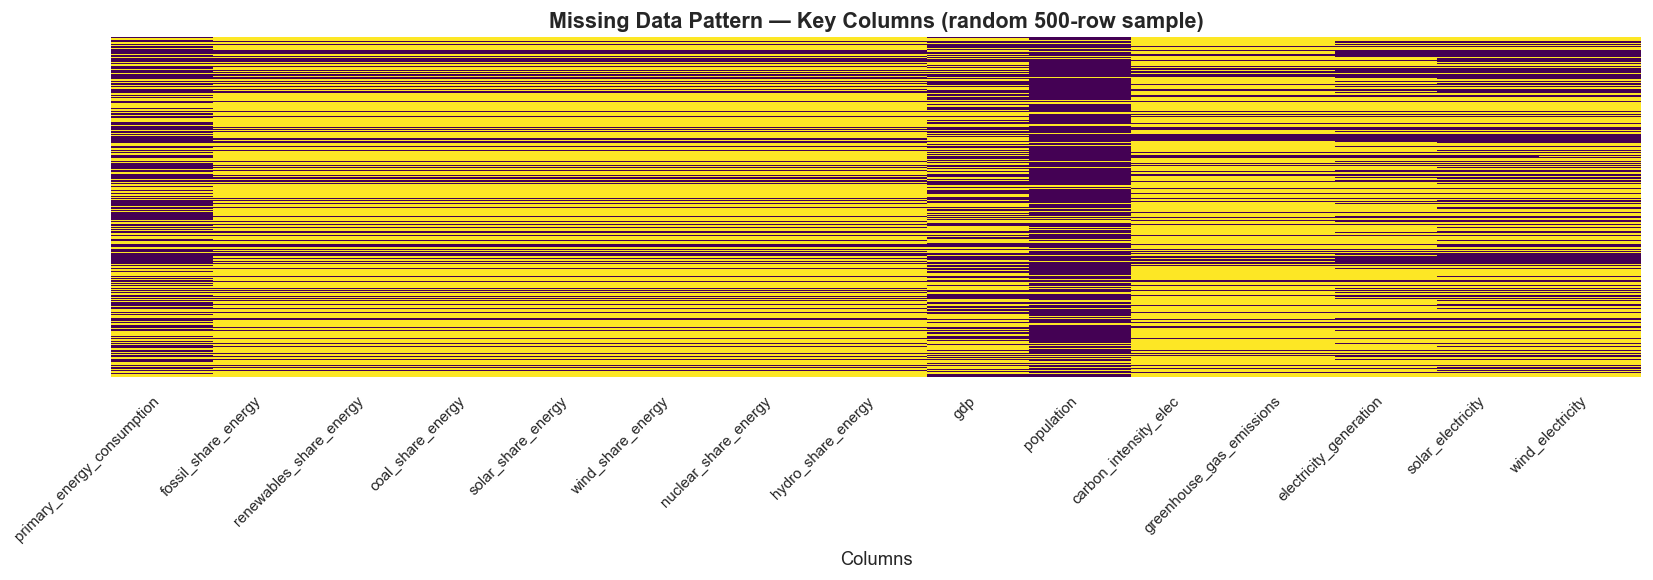

In [9]:
# ── Heatmap: missing pattern across key columns ──────────────────────────────
key_energy_cols = [
    'primary_energy_consumption', 'fossil_share_energy', 'renewables_share_energy',
    'coal_share_energy', 'solar_share_energy', 'wind_share_energy',
    'nuclear_share_energy', 'hydro_share_energy', 'gdp', 'population',
    'carbon_intensity_elec', 'greenhouse_gas_emissions',
    'electricity_generation', 'solar_electricity', 'wind_electricity'
]

sample = df[key_energy_cols].sample(min(500, len(df)), random_state=42)

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(sample.isnull(), cbar=False, yticklabels=False,
            cmap='viridis', ax=ax)
ax.set_title('Missing Data Pattern — Key Columns (random 500-row sample)', fontweight='bold')
ax.set_xlabel('Columns')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

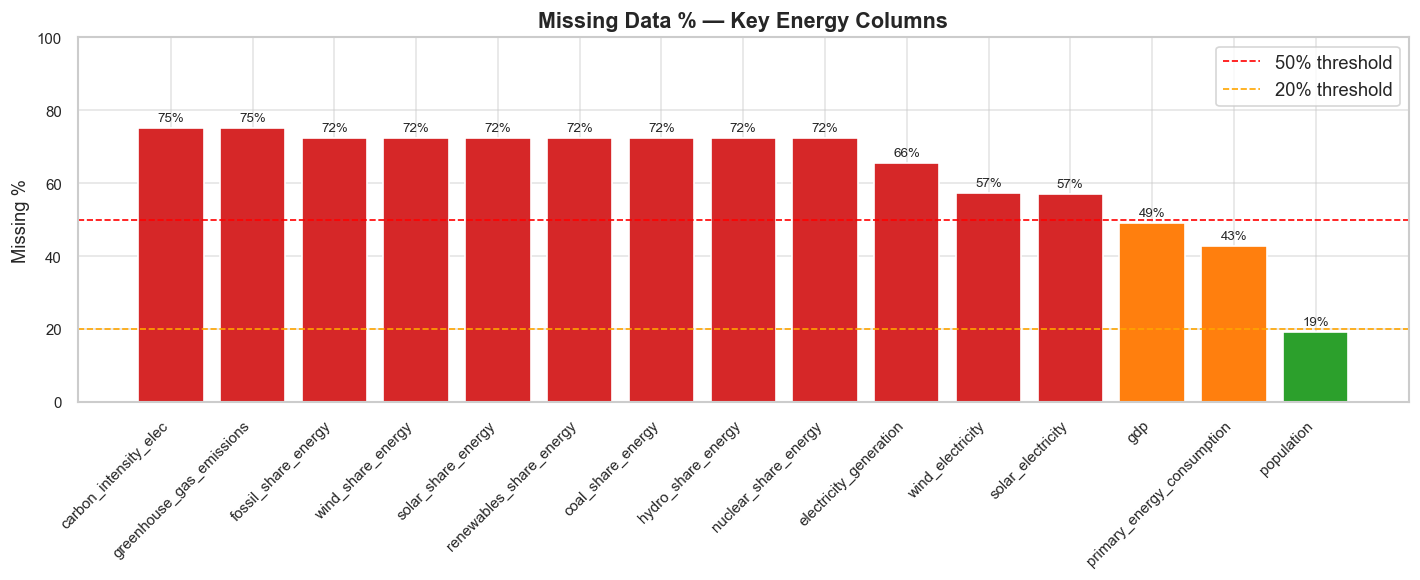

In [10]:
# ── Bar chart: missing % for key columns ────────────────────────────────────
miss_key = missing.loc[key_energy_cols, 'Missing %'].sort_values(ascending=False)

colors = ['#d62728' if v > 50 else '#ff7f0e' if v > 20 else '#2ca02c' for v in miss_key]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(miss_key.index, miss_key.values, color=colors, edgecolor='white')
ax.axhline(50, color='red',    linestyle='--', linewidth=1, label='50% threshold')
ax.axhline(20, color='orange', linestyle='--', linewidth=1, label='20% threshold')
ax.set_title('Missing Data % — Key Energy Columns', fontweight='bold')
ax.set_ylabel('Missing %')
ax.set_ylim(0, 100)
ax.legend()
plt.xticks(rotation=45, ha='right')
for bar, val in zip(bars, miss_key.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.0f}%', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

In [11]:
# ── RECOMMENDATION: Flag columns to drop / keep / impute ─────────────────────

# Columns suitable for analysis (low missingness)
usable_cols = missing[missing['Missing %'] <= 30].index.tolist()
print(f'Columns with ≤30% missing (recommended for modelling): {len(usable_cols)}')
print(usable_cols)

print()
# Columns to drop or treat carefully
drop_candidates = missing[missing['Missing %'] > 80].index.tolist()
print(f'Columns with >80% missing (consider dropping): {len(drop_candidates)}')
print(drop_candidates)

Columns with ≤30% missing (recommended for modelling): 10
['coal_prod_change_twh', 'coal_production', 'gas_prod_change_twh', 'iso_code', 'gas_production', 'oil_prod_change_twh', 'oil_production', 'population', 'year', 'country']

Columns with >80% missing (consider dropping): 6
['biofuel_cons_change_pct', 'solar_cons_change_pct', 'nuclear_cons_change_pct', 'wind_cons_change_pct', 'other_renewables_cons_change_pct', 'electricity_share_energy']


---
## 5. Data Quality & Anomaly Checks

Checks: duplicates, negative values, year/population out-of-range, string inconsistencies, share columns summing >100%.

In [12]:
# ── 5.1 Duplicates ───────────────────────────────────────────────────────────
n_dup = df.duplicated().sum()
n_dup_key = df.duplicated(subset=['country', 'year']).sum()
print(f'Fully duplicate rows    : {n_dup}')
print(f'Duplicate (country, year): {n_dup_key}')

if n_dup_key > 0:
    print('\n⚠️  Duplicates found on (country, year):')
    print(df[df.duplicated(subset=['country','year'], keep=False)][['country','year']].head(10))
else:
    print('✅ No duplicate (country, year) pairs — each row is unique.')

Fully duplicate rows    : 0
Duplicate (country, year): 0
✅ No duplicate (country, year) pairs — each row is unique.


In [13]:
# ── 5.2 Year range check ──────────────────────────────────────────────────────
valid_year_range = (1900, 2024)
invalid_years = df[(df['year'] < valid_year_range[0]) | (df['year'] > valid_year_range[1])]
print(f'Rows with year outside {valid_year_range}: {len(invalid_years)}')
if len(invalid_years) > 0:
    print(invalid_years[['country','year']].head())

Rows with year outside (1900, 2024): 0


In [14]:
# ── 5.3 Negative value check on columns that must be non-negative ─────────────
must_be_positive = [
    'primary_energy_consumption', 'population', 'gdp',
    'renewables_share_energy', 'fossil_share_energy',
    'solar_electricity', 'wind_electricity', 'nuclear_electricity'
]
must_be_positive_existing = [c for c in must_be_positive if c in df.columns]

print('=== Negative Value Check ===')
for col in must_be_positive_existing:
    neg = (df[col] < 0).sum()
    if neg > 0:
        print(f'⚠️  {col}: {neg} negative values')
    else:
        print(f'✅  {col}: OK')

=== Negative Value Check ===
✅  primary_energy_consumption: OK
✅  population: OK
✅  gdp: OK
✅  renewables_share_energy: OK
✅  fossil_share_energy: OK
✅  solar_electricity: OK
✅  wind_electricity: OK
✅  nuclear_electricity: OK


In [15]:
# ── 5.4 Share column sanity check: fossil + renewables + nuclear + hydro ≈ 100% ─
share_cols = ['fossil_share_energy', 'renewables_share_energy',
              'nuclear_share_energy', 'hydro_share_energy']
share_existing = [c for c in share_cols if c in df.columns]

df_share_check = df[share_existing].dropna()
df_share_check['total_share'] = df_share_check.sum(axis=1)

# Allow ±20% tolerance because columns are not perfectly exhaustive
outliers = df_share_check[(df_share_check['total_share'] > 120) | (df_share_check['total_share'] < 50)]
print(f'Share sum (fossil+renewables+nuclear+hydro) — median: {df_share_check["total_share"].median():.1f}%')
print(f'Rows where sum is outside 50–120%: {len(outliers)}')
print('(Some share columns are subsets of each other — overlapping definitions are expected)')

Share sum (fossil+renewables+nuclear+hydro) — median: 105.4%
Rows where sum is outside 50–120%: 1010
(Some share columns are subsets of each other — overlapping definitions are expected)


In [16]:
# ── 5.5 Country name / string quality check ───────────────────────────────────
countries = df['country'].unique()

# Check for leading/trailing whitespace
whitespace_issues = [c for c in countries if c != c.strip()]
print(f'Country names with leading/trailing whitespace: {len(whitespace_issues)}')

# Check for all-caps entries
all_caps = [c for c in countries if c.isupper() and len(c) > 3]
print(f'Country names that are all-caps (possible encoding issue): {all_caps}')

# Check for parenthetical source suffixes — these are regional aggregates
with_parens = [c for c in countries if '(' in c]
print(f'\nEntities with parenthetical source suffix (Ember, EI, EIA, Shift) — regional aggregates:')
print(with_parens)

print()
print('=== RECOMMENDATION ===')
print('Entries with source suffixes (e.g. "Africa (Ember)", "Asia (EIA)") are regional aggregates.')
print('For country-level analysis: filter df[df["iso_code"].notna()]')
print('For global/regional analysis: include them OR use "World" only.')

Country names with leading/trailing whitespace: 0
Country names that are all-caps (possible encoding issue): ['CIS (EI)', 'OECD (EI)', 'OECD (EIA)', 'OPEC (EI)', 'OPEC (EIA)', 'USSR']

Entities with parenthetical source suffix (Ember, EI, EIA, Shift) — regional aggregates:
['ASEAN (Ember)', 'Africa (EI)', 'Africa (EIA)', 'Africa (Ember)', 'Africa (Shift)', 'Asia & Oceania (EIA)', 'Asia (Ember)', 'Asia Pacific (EI)', 'Asia and Oceania (Shift)', 'Australia and New Zealand (EIA)', 'CIS (EI)', 'Central & South America (EIA)', 'Central America (EI)', 'Central and South America (Shift)', 'EU (Ember)', 'EU28 (Shift)', 'Eastern Africa (EI)', 'Eastern Europe and Eurasia (EIA)', 'Eurasia (EIA)', 'Eurasia (Shift)', 'Europe (EI)', 'Europe (EIA)', 'Europe (Ember)', 'Europe (Shift)', 'European Union (27)', 'G20 (Ember)', 'G7 (Ember)', 'Latin America and Caribbean (Ember)', 'Micronesia (country)', 'Middle Africa (EI)', 'Middle East (EI)', 'Middle East (EIA)', 'Middle East (Ember)', 'Middle East (Shif

In [17]:
# ── 5.6 ISO code format check ────────────────────────────────────────────────
iso_issues = df[df['iso_code'].notna() & (df['iso_code'].str.len() != 3)]
print(f'ISO codes that are not exactly 3 characters: {len(iso_issues)}')
if len(iso_issues) > 0:
    print(iso_issues[['country','iso_code']].drop_duplicates().head())

ISO codes that are not exactly 3 characters: 0


In [18]:
# ── 5.7 Statistical outlier flagging (IQR method) ────────────────────────────
def iqr_outliers(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return ((series < q1 - 3*iqr) | (series > q3 + 3*iqr)).sum()

check_cols = ['primary_energy_consumption', 'gdp', 'population',
              'fossil_share_energy', 'renewables_share_energy']
check_cols = [c for c in check_cols if c in df.columns]

print('=== Extreme Outliers (3×IQR rule) ===')
for col in check_cols:
    n = iqr_outliers(df[col].dropna())
    print(f'{col:45s}: {n:>5} outliers')

=== Extreme Outliers (3×IQR rule) ===
primary_energy_consumption                   :  1990 outliers
gdp                                          :  1132 outliers
population                                   :  2107 outliers
fossil_share_energy                          :    78 outliers
renewables_share_energy                      :   138 outliers


---
## 6. Univariate Analysis

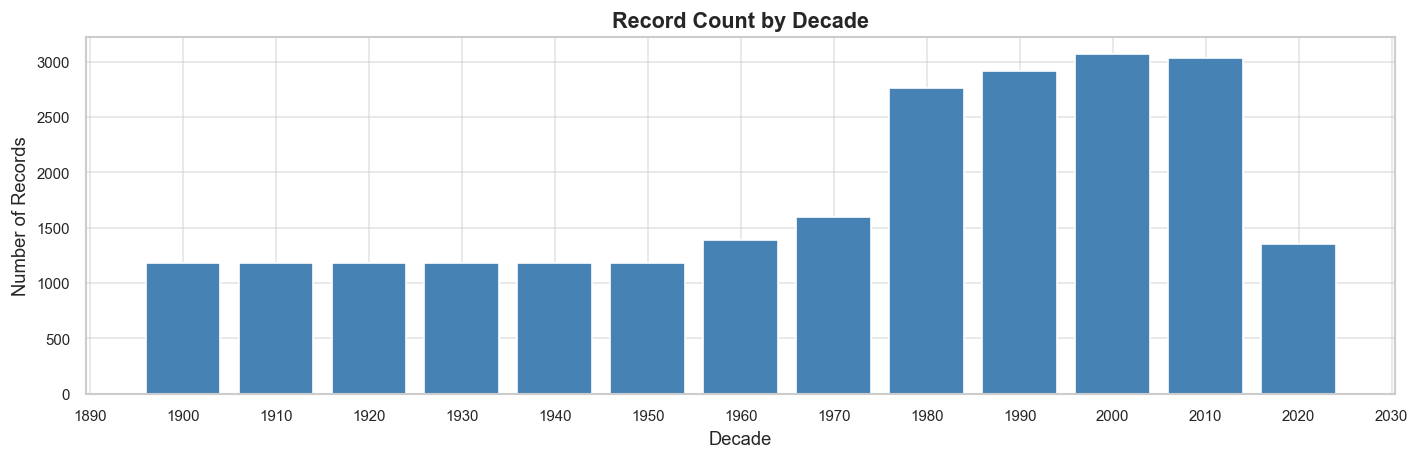

In [19]:
# ── 6.1 Distribution of year (record count per decade) ───────────────────────
df['decade'] = (df['year'] // 10) * 10

fig, ax = plt.subplots(figsize=(12, 4))
decade_counts = df.groupby('decade').size()
ax.bar(decade_counts.index, decade_counts.values, width=8, color='steelblue', edgecolor='white')
ax.set_title('Record Count by Decade', fontweight='bold')
ax.set_xlabel('Decade')
ax.set_ylabel('Number of Records')
ax.xaxis.set_major_locator(mticker.MultipleLocator(10))
plt.tight_layout()
plt.show()

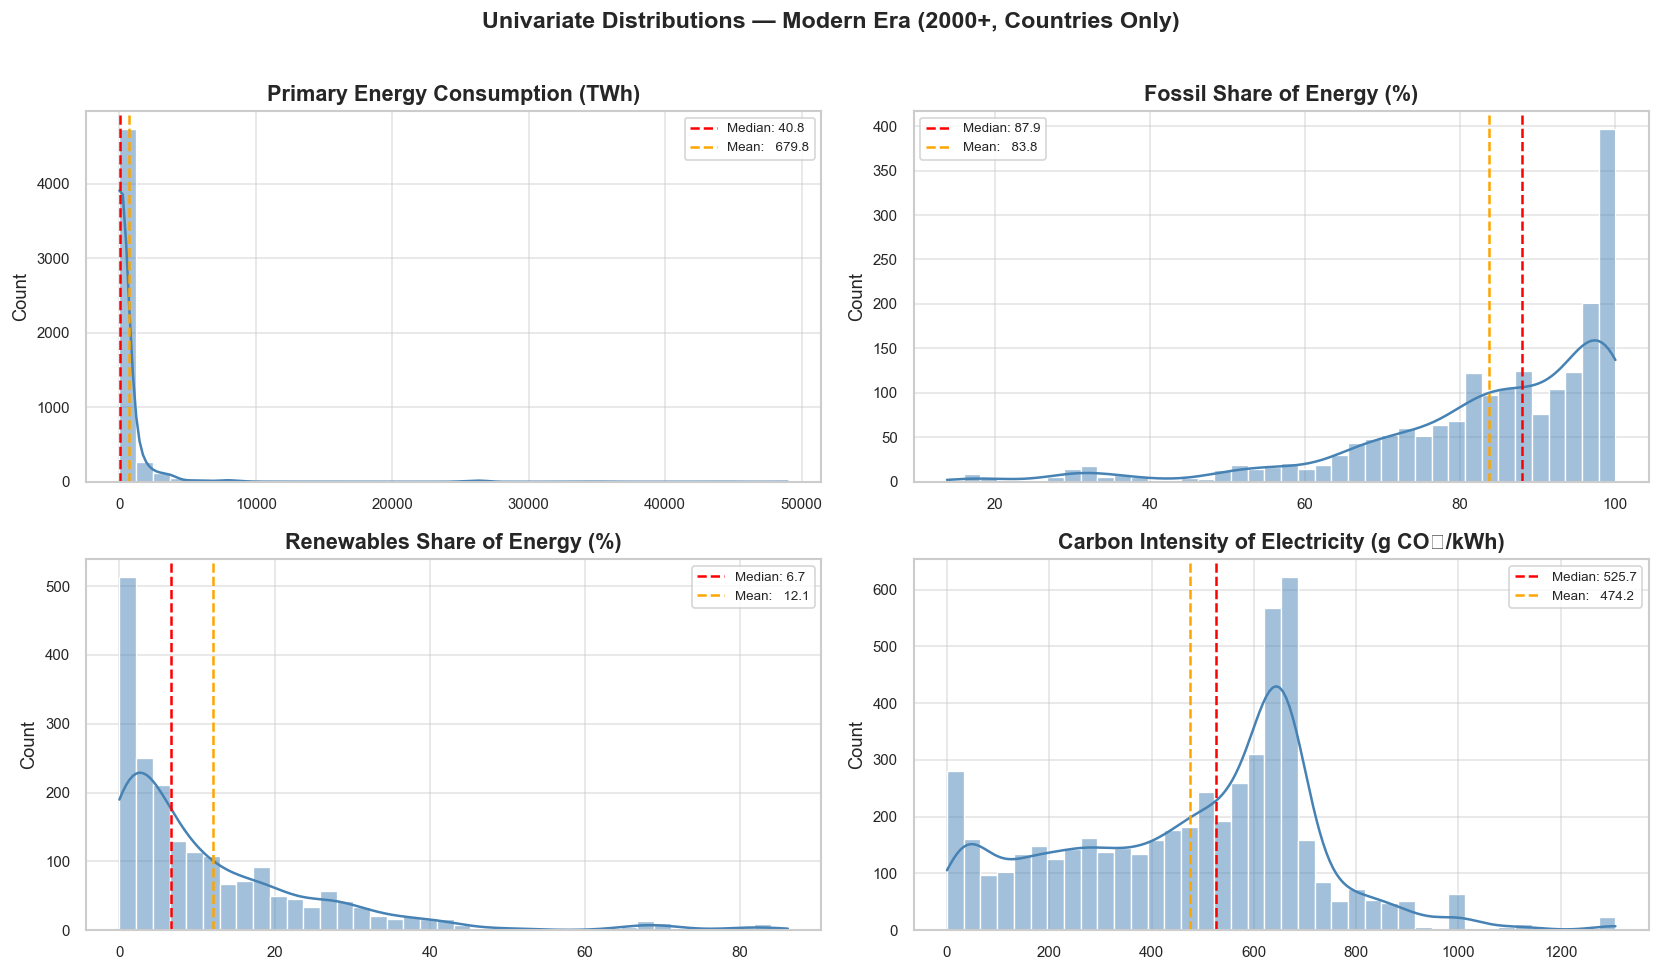


Key Stats:
       primary_energy_consumption  fossil_share_energy  \
count                     5284.00              1975.00   
mean                       679.78                83.76   
std                       3007.96                16.75   
min                          0.00                13.87   
25%                          5.36                76.40   
50%                         40.80                87.93   
75%                        305.46                96.87   
max                      48987.10               100.00   

       renewables_share_energy  carbon_intensity_elec  
count                  1975.00                5124.00  
mean                     12.09                 474.18  
std                      14.67                 248.09  
min                       0.00                   0.00  
25%                       2.01                 279.83  
50%                       6.65                 525.68  
75%                      17.62                 652.17  
max              

In [20]:
# ── 6.2 Distribution of key energy metrics (modern era: 2000+, actual countries only) ─
df_modern = df[(df['year'] >= 2000) & df['iso_code'].notna()].copy()

plot_cols = {
    'primary_energy_consumption': 'Primary Energy Consumption (TWh)',
    'fossil_share_energy':        'Fossil Share of Energy (%)',
    'renewables_share_energy':    'Renewables Share of Energy (%)',
    'carbon_intensity_elec':      'Carbon Intensity of Electricity (g CO₂/kWh)',
}
plot_cols = {k: v for k, v in plot_cols.items() if k in df.columns}

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, (col, label) in enumerate(plot_cols.items()):
    data = df_modern[col].dropna()
    sns.histplot(data, bins=40, kde=True, ax=axes[i], color='steelblue')
    axes[i].axvline(data.median(), color='red',    linestyle='--', label=f'Median: {data.median():.1f}')
    axes[i].axvline(data.mean(),   color='orange', linestyle='--', label=f'Mean:   {data.mean():.1f}')
    axes[i].set_title(label, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].legend(fontsize=8)

plt.suptitle('Univariate Distributions — Modern Era (2000+, Countries Only)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('\nKey Stats:')
print(df_modern[list(plot_cols.keys())].describe().round(2))

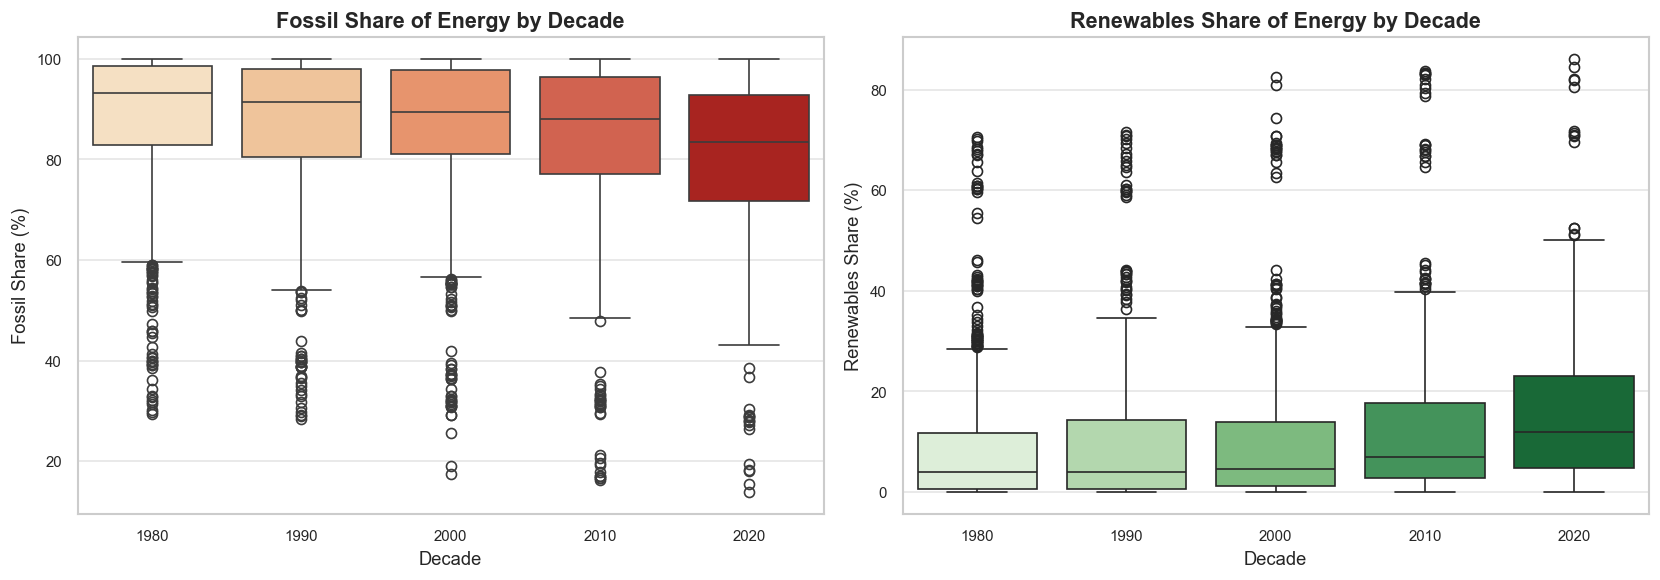

In [21]:
# ── 6.3 Boxplots: fossil vs renewables share by decade ───────────────────────
df_box = df[(df['year'] >= 1980) & df['iso_code'].notna() &
            df['fossil_share_energy'].notna() &
            df['renewables_share_energy'].notna()].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df_box, x='decade', y='fossil_share_energy',
            palette='OrRd', ax=axes[0])
axes[0].set_title('Fossil Share of Energy by Decade', fontweight='bold')
axes[0].set_xlabel('Decade')
axes[0].set_ylabel('Fossil Share (%)')

sns.boxplot(data=df_box, x='decade', y='renewables_share_energy',
            palette='Greens', ax=axes[1])
axes[1].set_title('Renewables Share of Energy by Decade', fontweight='bold')
axes[1].set_xlabel('Decade')
axes[1].set_ylabel('Renewables Share (%)')

plt.tight_layout()
plt.show()

---
## 7. Bivariate & Correlation Analysis

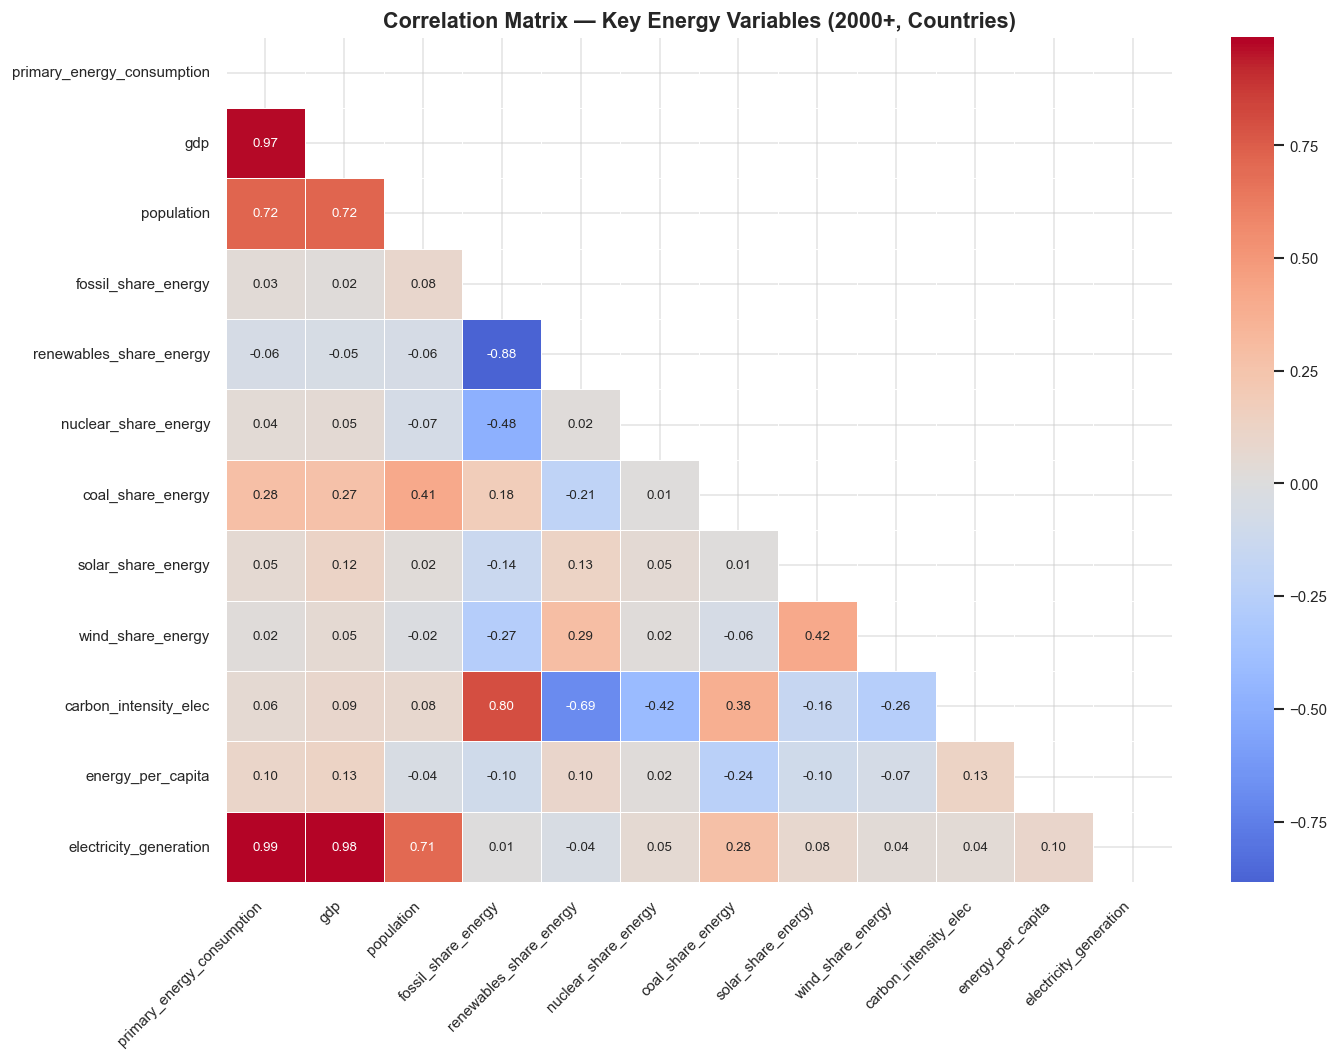


Top 10 strongest correlations:
                  Var1                       Var2  Correlation
electricity_generation primary_energy_consumption     0.989436
electricity_generation                        gdp     0.976569
                   gdp primary_energy_consumption     0.972729
   fossil_share_energy    renewables_share_energy    -0.884436
 carbon_intensity_elec        fossil_share_energy     0.799223
                   gdp                 population     0.724243
            population primary_energy_consumption     0.720711
electricity_generation                 population     0.709397
 carbon_intensity_elec    renewables_share_energy    -0.691078
   fossil_share_energy       nuclear_share_energy    -0.483826


In [22]:
# ── 7.1 Correlation heatmap ───────────────────────────────────────────────────
corr_cols = [
    'primary_energy_consumption', 'gdp', 'population',
    'fossil_share_energy', 'renewables_share_energy', 'nuclear_share_energy',
    'coal_share_energy', 'solar_share_energy', 'wind_share_energy',
    'carbon_intensity_elec', 'energy_per_capita', 'electricity_generation'
]
corr_cols = [c for c in corr_cols if c in df.columns]

corr_matrix = df_modern[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5,
            annot_kws={'size': 8}, ax=ax)
ax.set_title('Correlation Matrix — Key Energy Variables (2000+, Countries)', fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Print strongest correlations
pairs = corr_matrix.unstack().reset_index()
pairs.columns = ['Var1','Var2','Correlation']
pairs = pairs[pairs['Var1'] < pairs['Var2']].sort_values('Correlation', key=abs, ascending=False)
print('\nTop 10 strongest correlations:')
print(pairs.head(10).to_string(index=False))

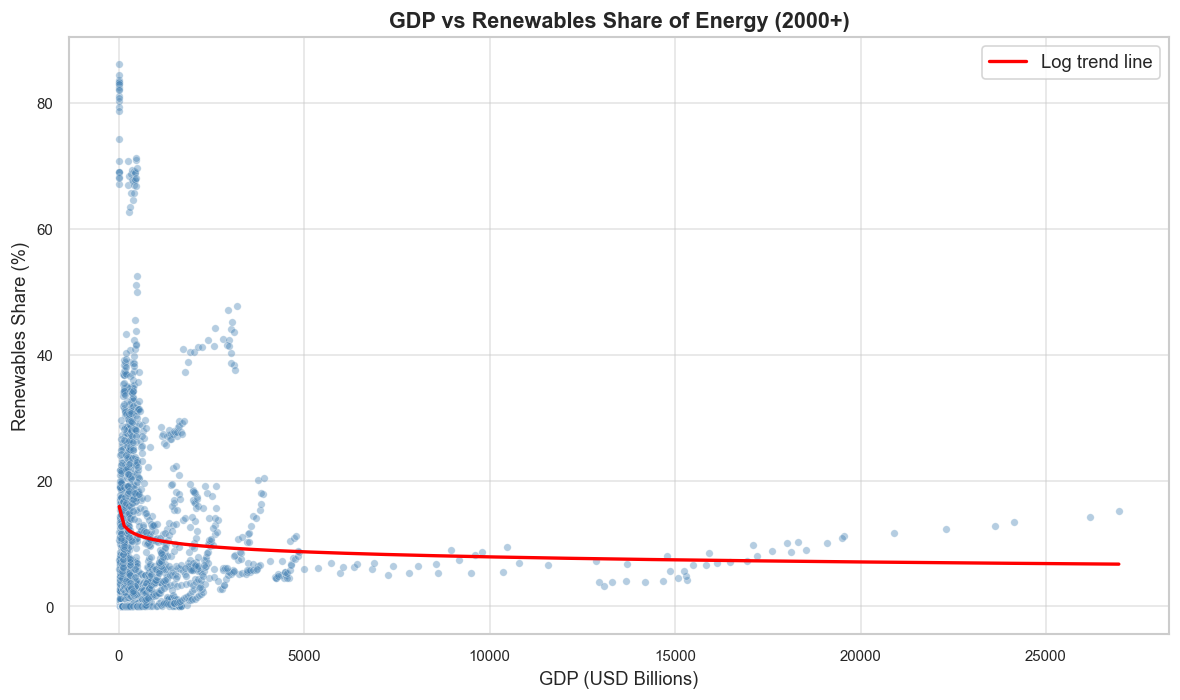

In [23]:
# ── 7.2 Scatter: GDP vs Renewables Share ─────────────────────────────────────
scatter_df = df_modern[['gdp','renewables_share_energy','country']].dropna()
scatter_df['gdp_bn'] = scatter_df['gdp'] / 1e9  # convert to USD billions

fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=scatter_df, x='gdp_bn', y='renewables_share_energy',
                alpha=0.4, color='steelblue', s=20, ax=ax)
# Add a trend line
from numpy.polynomial.polynomial import polyfit
x_clean = scatter_df['gdp_bn'].values
y_clean = scatter_df['renewables_share_energy'].values
c, m = polyfit(np.log1p(x_clean), y_clean, 1)
x_range = np.linspace(x_clean.min(), x_clean.max(), 200)
ax.plot(x_range, c + m * np.log1p(x_range), color='red', linewidth=2, label='Log trend line')

ax.set_title('GDP vs Renewables Share of Energy (2000+)', fontweight='bold')
ax.set_xlabel('GDP (USD Billions)')
ax.set_ylabel('Renewables Share (%)')
ax.legend()
plt.tight_layout()
plt.show()

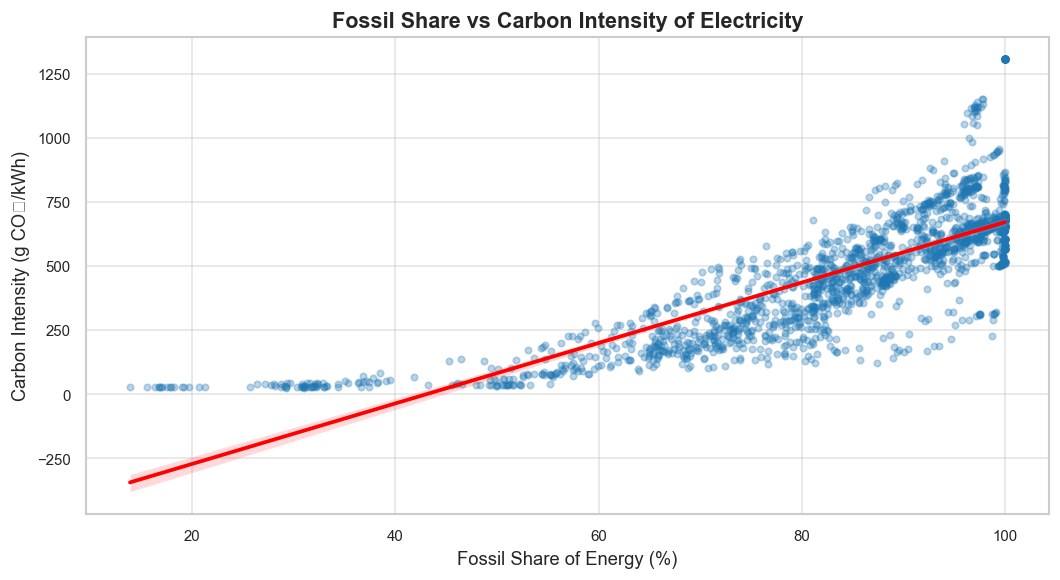

In [24]:
# ── 7.3 Scatter: Fossil Share vs Carbon Intensity ────────────────────────────
if 'carbon_intensity_elec' in df.columns:
    ci_df = df_modern[['fossil_share_energy','carbon_intensity_elec']].dropna()

    fig, ax = plt.subplots(figsize=(9, 5))
    sns.regplot(data=ci_df, x='fossil_share_energy', y='carbon_intensity_elec',
                scatter_kws={'alpha': 0.3, 's': 15}, line_kws={'color': 'red'}, ax=ax)
    ax.set_title('Fossil Share vs Carbon Intensity of Electricity', fontweight='bold')
    ax.set_xlabel('Fossil Share of Energy (%)')
    ax.set_ylabel('Carbon Intensity (g CO₂/kWh)')
    plt.tight_layout()
    plt.show()

---
## 8. Time-Series Trends (Global)

In [25]:
# ── Use 'World' row for global totals ─────────────────────────────────────────
df_world = df[df['country'] == 'World'].copy()
df_world = df_world.sort_values('year')

print(f"World rows: {len(df_world)} | Year range: {df_world['year'].min()}–{df_world['year'].max()}")

World rows: 125 | Year range: 1900–2024


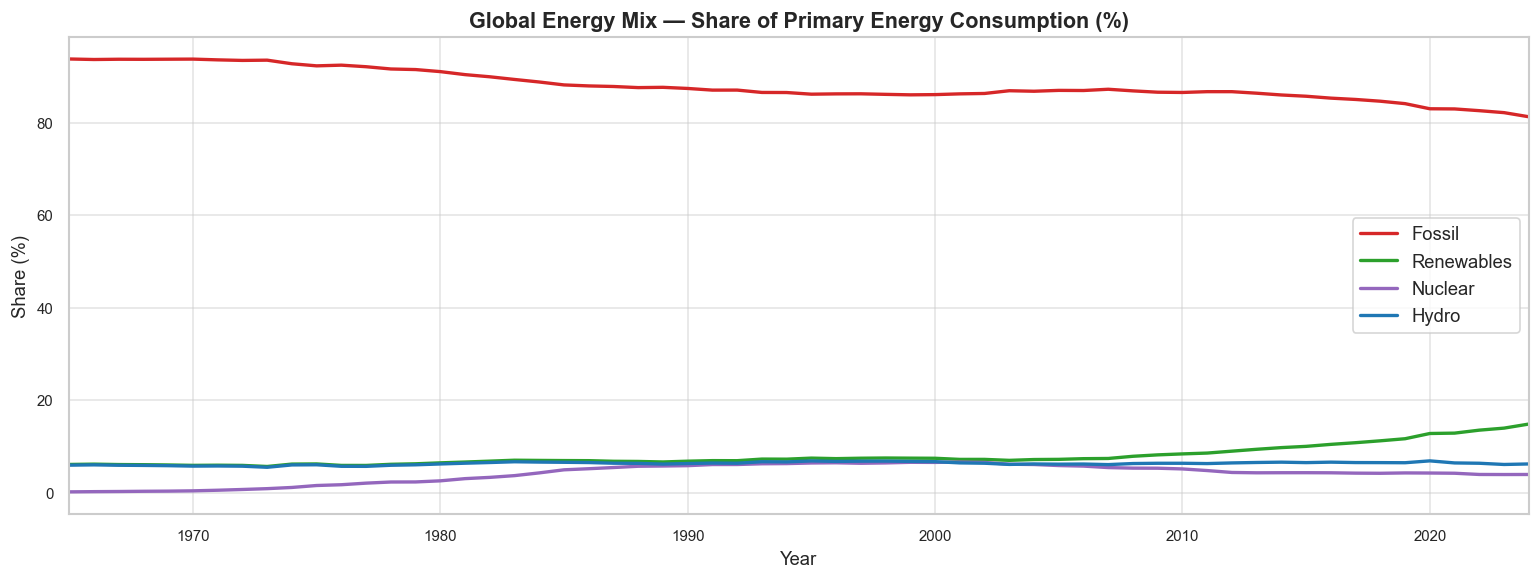

In [26]:
# ── 8.1 Global energy mix over time ──────────────────────────────────────────
mix_cols = {
    'fossil_share_energy':      'Fossil',
    'renewables_share_energy':  'Renewables',
    'nuclear_share_energy':     'Nuclear',
    'hydro_share_energy':       'Hydro',
}
mix_existing = {k: v for k, v in mix_cols.items() if k in df_world.columns}

df_mix = df_world[['year'] + list(mix_existing.keys())].dropna(subset=list(mix_existing.keys()), how='all')

fig, ax = plt.subplots(figsize=(13, 5))
colors = ['#d62728', '#2ca02c', '#9467bd', '#1f77b4']
for (col, label), color in zip(mix_existing.items(), colors):
    ax.plot(df_mix['year'], df_mix[col], label=label, linewidth=2, color=color)

ax.set_title('Global Energy Mix — Share of Primary Energy Consumption (%)', fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Share (%)')
ax.legend()
ax.set_xlim(1965, df_world['year'].max())
plt.tight_layout()
plt.show()

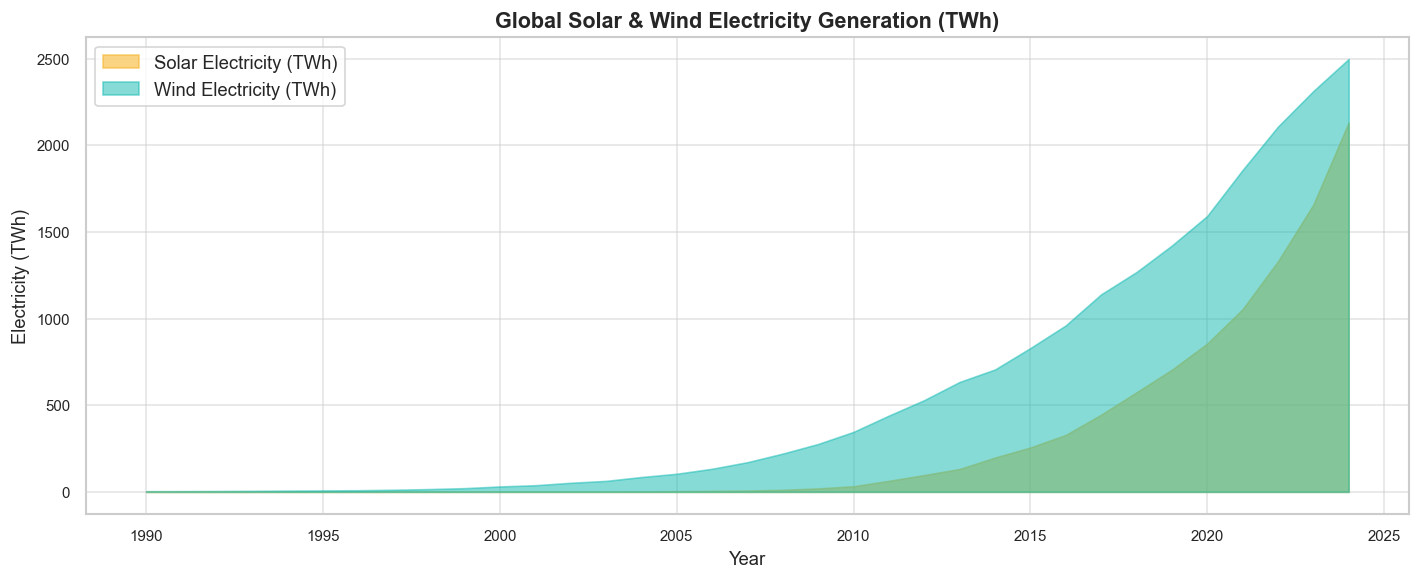

In [27]:
# ── 8.2 Solar & Wind growth (global, recent years) ────────────────────────────
solar_wind_cols = ['year']
if 'solar_electricity' in df_world.columns:  solar_wind_cols.append('solar_electricity')
if 'wind_electricity'  in df_world.columns:  solar_wind_cols.append('wind_electricity')

df_sw = df_world[solar_wind_cols].dropna().query('year >= 1990')

fig, ax = plt.subplots(figsize=(12, 5))
if 'solar_electricity' in df_sw.columns:
    ax.fill_between(df_sw['year'], df_sw['solar_electricity'], alpha=0.6,
                    label='Solar Electricity (TWh)', color='#f7b731')
if 'wind_electricity' in df_sw.columns:
    ax.fill_between(df_sw['year'], df_sw['wind_electricity'], alpha=0.5,
                    label='Wind Electricity (TWh)', color='#0fb9b1')

ax.set_title('Global Solar & Wind Electricity Generation (TWh)', fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Electricity (TWh)')
ax.legend()
plt.tight_layout()
plt.show()

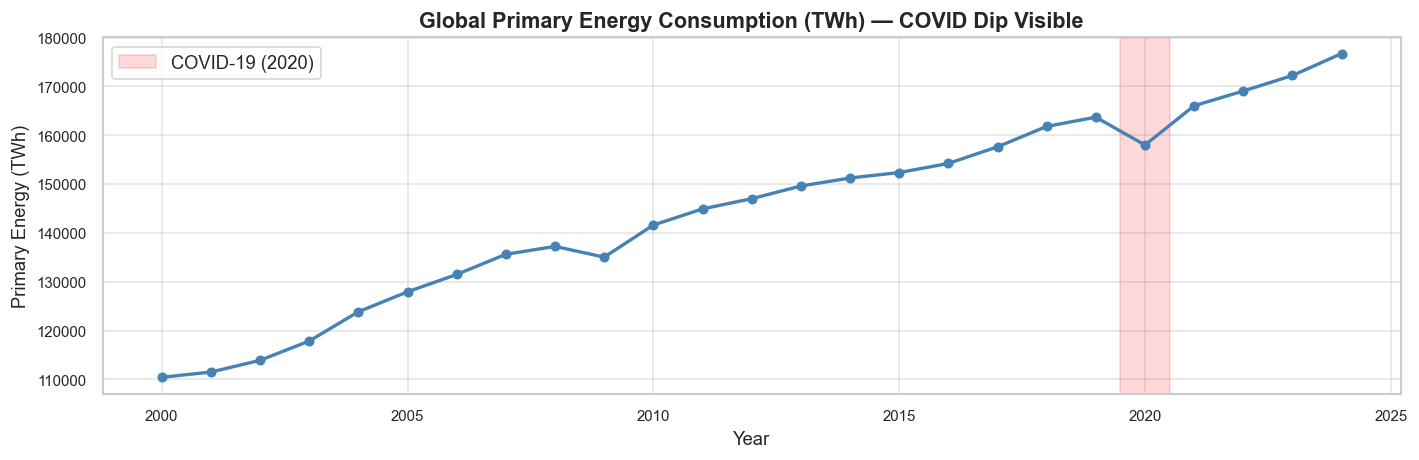

In [28]:
# ── 8.3 COVID-19 impact — detect 2020 dip in primary energy consumption ──────
if 'primary_energy_consumption' in df_world.columns:
    df_pec = df_world[['year', 'primary_energy_consumption']].dropna().query('year >= 2000')

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(df_pec['year'], df_pec['primary_energy_consumption'],
            marker='o', markersize=5, linewidth=2, color='steelblue')
    ax.axvspan(2019.5, 2020.5, color='red', alpha=0.15, label='COVID-19 (2020)')
    ax.set_title('Global Primary Energy Consumption (TWh) — COVID Dip Visible', fontweight='bold')
    ax.set_xlabel('Year')
    ax.set_ylabel('Primary Energy (TWh)')
    ax.legend()
    plt.tight_layout()
    plt.show()

---
## 9. Regional & Country-Level Analysis

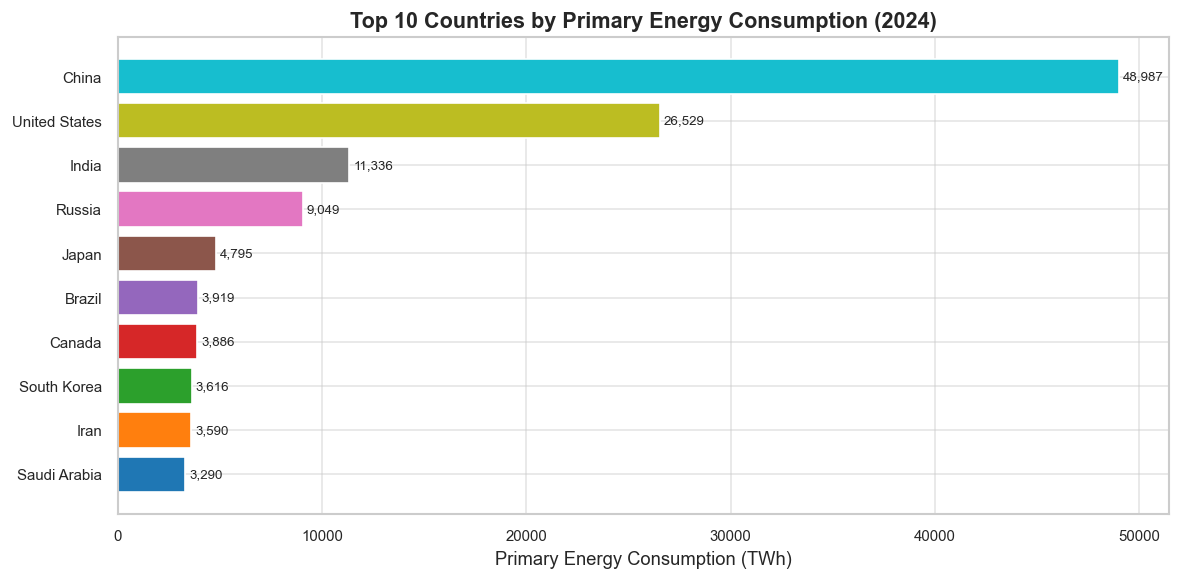

In [29]:
# ── 9.1 Top 10 countries by primary energy consumption (latest year) ───────────
latest_year = df[df['iso_code'].notna()]['year'].max()
df_latest = df[(df['year'] == latest_year) & df['iso_code'].notna() &
               df['primary_energy_consumption'].notna()].copy()

top10_energy = df_latest.nlargest(10, 'primary_energy_consumption')[['country','primary_energy_consumption']]

fig, ax = plt.subplots(figsize=(10, 5))
colors_bar = sns.color_palette('tab10', 10)
bars = ax.barh(top10_energy['country'][::-1], top10_energy['primary_energy_consumption'][::-1],
               color=colors_bar)
ax.set_title(f'Top 10 Countries by Primary Energy Consumption ({latest_year})', fontweight='bold')
ax.set_xlabel('Primary Energy Consumption (TWh)')
for bar in bars:
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():,.0f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

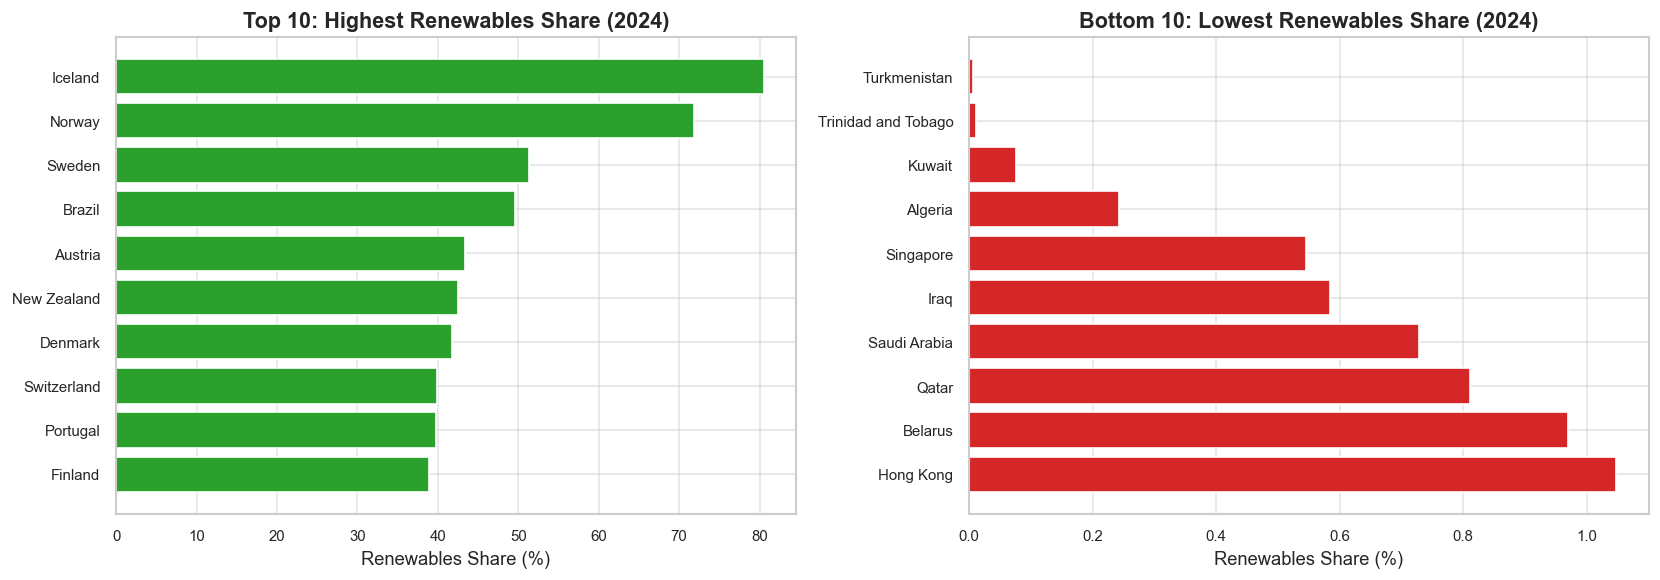

In [30]:
# ── 9.2 Top 10 and Bottom 10 countries by renewables share (latest year) ──────
df_renew = df_latest[df_latest['renewables_share_energy'].notna()].copy()

top10_ren = df_renew.nlargest(10,  'renewables_share_energy')[['country','renewables_share_energy']]
bot10_ren = df_renew.nsmallest(10, 'renewables_share_energy')[['country','renewables_share_energy']]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(top10_ren['country'][::-1], top10_ren['renewables_share_energy'][::-1],
             color='#2ca02c')
axes[0].set_title(f'Top 10: Highest Renewables Share ({latest_year})', fontweight='bold')
axes[0].set_xlabel('Renewables Share (%)')

axes[1].barh(bot10_ren['country'][::-1], bot10_ren['renewables_share_energy'][::-1],
             color='#d62728')
axes[1].set_title(f'Bottom 10: Lowest Renewables Share ({latest_year})', fontweight='bold')
axes[1].set_xlabel('Renewables Share (%)')

plt.tight_layout()
plt.show()

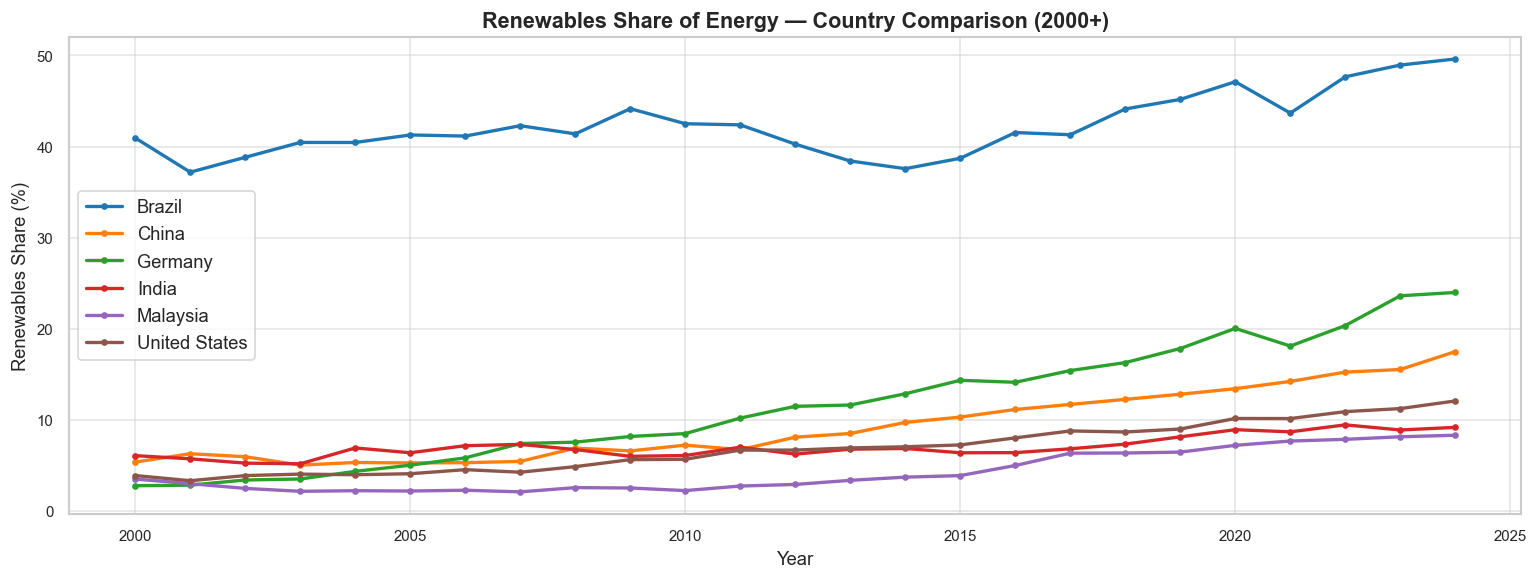

In [31]:
# ── 9.3 Time-series comparison: select countries ─────────────────────────────
COUNTRIES_TO_COMPARE = ['United States', 'China', 'Germany', 'India', 'Malaysia', 'Brazil']
# Adjust the list above as needed

df_sel = df[(df['country'].isin(COUNTRIES_TO_COMPARE)) &
            (df['year'] >= 2000) &
            df['renewables_share_energy'].notna()].copy()

fig, ax = plt.subplots(figsize=(13, 5))
for country, grp in df_sel.groupby('country'):
    ax.plot(grp['year'], grp['renewables_share_energy'], marker='o',
            markersize=3, linewidth=2, label=country)

ax.set_title('Renewables Share of Energy — Country Comparison (2000+)', fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Renewables Share (%)')
ax.legend()
plt.tight_layout()
plt.show()

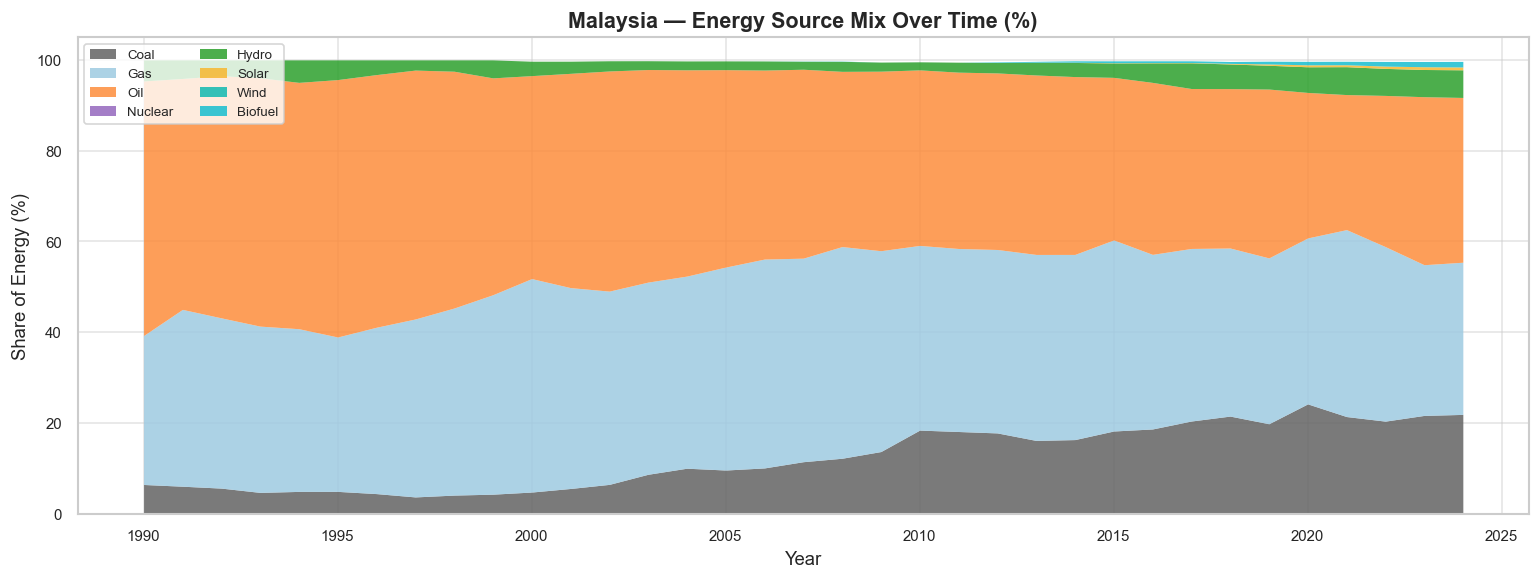

In [32]:
# ── 9.4 Stacked area: energy source breakdown for a specific country ──────────
COUNTRY_FOCUS = 'Malaysia'  # ← Change as needed

df_focus = df[(df['country'] == COUNTRY_FOCUS) & (df['year'] >= 1990)].copy()

area_cols = {
    'coal_share_energy':        'Coal',
    'gas_share_energy':         'Gas',
    'oil_share_energy':         'Oil',
    'nuclear_share_energy':     'Nuclear',
    'hydro_share_energy':       'Hydro',
    'solar_share_energy':       'Solar',
    'wind_share_energy':        'Wind',
    'biofuel_share_energy':     'Biofuel',
}
area_existing = {k: v for k, v in area_cols.items() if k in df_focus.columns}

df_area = df_focus[['year'] + list(area_existing.keys())].set_index('year')
df_area = df_area.dropna(how='all').fillna(0)
df_area.columns = list(area_existing.values())

fig, ax = plt.subplots(figsize=(13, 5))
area_colors = ['#636363','#9ecae1','#fd8d3c','#9467bd','#2ca02c','#f7b731','#0fb9b1','#17becf']
df_area.plot.area(ax=ax, color=area_colors[:len(df_area.columns)], alpha=0.85, linewidth=0)
ax.set_title(f'{COUNTRY_FOCUS} — Energy Source Mix Over Time (%)', fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Share of Energy (%)')
ax.legend(loc='upper left', fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

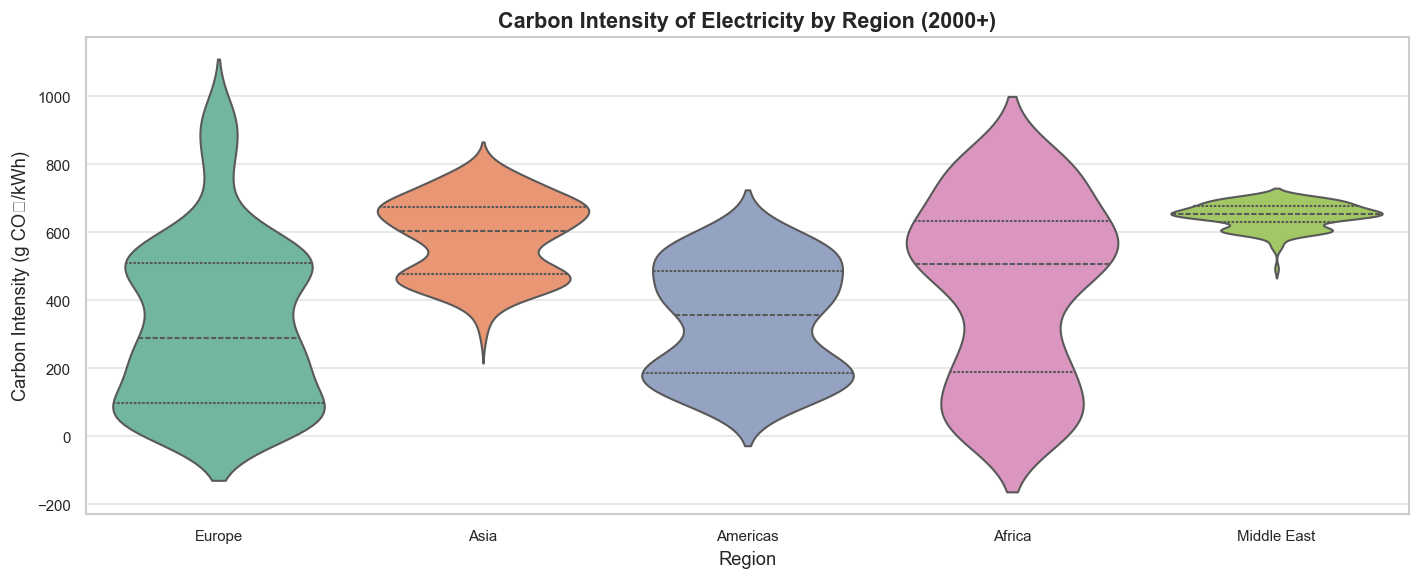

In [33]:
# ── 9.5 Violin plot: carbon intensity by continent proxy (using country sets) ─
# Assign rough region tags based on well-known groupings
region_map = {
    'Europe': [
        'Germany','France','United Kingdom','Italy','Spain','Poland',
        'Netherlands','Sweden','Norway','Denmark','Austria','Belgium'
    ],
    'Asia': [
        'China','India','Japan','South Korea','Indonesia','Malaysia',
        'Thailand','Vietnam','Bangladesh','Pakistan'
    ],
    'Americas': [
        'United States','Canada','Brazil','Mexico','Argentina','Colombia','Chile'
    ],
    'Africa': [
        'South Africa','Nigeria','Egypt','Kenya','Ethiopia','Morocco','Ghana'
    ],
    'Middle East': [
        'Saudi Arabia','Iran','Iraq','United Arab Emirates','Qatar','Kuwait'
    ],
}

rows = []
for region, countries_list in region_map.items():
    sub = df_modern[df_modern['country'].isin(countries_list) &
                    df_modern['carbon_intensity_elec'].notna()].copy()
    sub['region'] = region
    rows.append(sub)

if rows and 'carbon_intensity_elec' in df.columns:
    df_region = pd.concat(rows)

    fig, ax = plt.subplots(figsize=(12, 5))
    sns.violinplot(data=df_region, x='region', y='carbon_intensity_elec',
                   palette='Set2', inner='quartile', ax=ax)
    ax.set_title('Carbon Intensity of Electricity by Region (2000+)', fontweight='bold')
    ax.set_xlabel('Region')
    ax.set_ylabel('Carbon Intensity (g CO₂/kWh)')
    plt.tight_layout()
    plt.show()

---
## 10. EDA Summary

In [34]:
print('=' * 65)
print('                  EDA SUMMARY — WorldEnergy.csv')
print('=' * 65)

print(f"""
DATASET
  Rows    : {df.shape[0]:,}
  Columns : {df.shape[1]}
  Years   : {int(df['year'].min())} – {int(df['year'].max())}
  Entities: {df['country'].nunique()} (incl. {regional_groups} regional aggregates)

MISSING DATA
  Columns with any missing    : {len(missing_nonzero)} / {df.shape[1]}
  Columns >80% missing        : {len(drop_candidates)} (drop-candidates)
  Columns ≤30% missing        : {len(usable_cols)} (analysis-ready)
  Root cause                  : Pre-1990 data sparse; solar/wind near-zero before 2000

DATA QUALITY
  Duplicate (country,year)    : {n_dup_key}
  Invalid year range          : {len(invalid_years)}
  ISO code format issues      : {len(iso_issues)}
  ⚠️  Regional aggregates (no ISO): {regional_groups} entities — filter for country analysis

KEY FINDINGS
  • Fossil fuels dominated globally throughout the dataset (>75% share)
  • Solar and wind electricity grew exponentially post-2010
  • COVID-19 (2020) visible as a dip in global primary energy consumption
  • Strong positive correlation: fossil_share_energy ↔ carbon_intensity_elec
  • GDP correlates weakly with renewables share — policy matters more than wealth

NEXT STEPS
  1. Filter to countries only: df[df['iso_code'].notna()]
  2. Limit to 2000+ for modern energy analysis (data completeness improves)
  3. Drop or impute columns with >80% missing before any ML modelling
  4. Consider time-series forecasting (Prophet / ARIMA) on World-level renewables share
  5. Cluster countries by 2023 energy profile using k-means on share columns
""")

                  EDA SUMMARY — WorldEnergy.csv

DATASET
  Rows    : 23,195
  Columns : 131
  Years   : 1900 – 2024
  Entities: 314 (incl. 94 regional aggregates)

MISSING DATA
  Columns with any missing    : 128 / 131
  Columns >80% missing        : 6 (drop-candidates)
  Columns ≤30% missing        : 10 (analysis-ready)
  Root cause                  : Pre-1990 data sparse; solar/wind near-zero before 2000

DATA QUALITY
  Duplicate (country,year)    : 0
  Invalid year range          : 0
  ISO code format issues      : 0
  ⚠️  Regional aggregates (no ISO): 94 entities — filter for country analysis

KEY FINDINGS
  • Fossil fuels dominated globally throughout the dataset (>75% share)
  • Solar and wind electricity grew exponentially post-2010
  • COVID-19 (2020) visible as a dip in global primary energy consumption
  • Strong positive correlation: fossil_share_energy ↔ carbon_intensity_elec
  • GDP correlates weakly with renewables share — policy matters more than wealth

NEXT STEPS
  1. 